# Imports

In [1]:
from lineagetree import read_from_mastodon
import numpy as np
import matplotlib.pyplot as plt
import h5py

# CUSTOM FUNCTIONS
import watermasks.utils as utils
import watermasks.main as main

# Data loading

In [ ]:
# --- LOAD DIRECTORIES FOR DATA AND FILES ---
path_h5, path_xml, path_mast, dir_input_images, dir_output_masks = utils.paths('JR_22-10-18')

VIEW='0' # Choose dataset view

# IMPORT REG. MATRICES AND LINEAGETREE
R_of_t = utils.import_registration_mats_multiview(path_xml, 0, 500)
lT = read_from_mastodon(path_mast)

TP = 500 # Choose timepoint

# IMPORT INPUT IMAGE
with h5py.File(path_h5, "r") as f5:
    raw_image = f5[f't00{TP}'][f's0{VIEW}']['2']['cells'][:]

# Data manipulation & image proccessing

In [3]:
# CALCULATE SCALING FACTORS
shape_full_h5 = np.array([300, 1888, 2100]) # for no downscaling (0-th level of the hdf5), (as measured in T7_3 data (dir = H:))
shape_raw_image = np.array(np.shape(raw_image))
scaling = shape_raw_image/shape_full_h5
print(f'full image shape = {shape_full_h5}\n2nd h5 layer has shape = {shape_raw_image} \n-scaling ratio is [z, y, x] = {scaling}')

# GET THE REGISTERED MASTODON POSITIONS AT CURRENT TIMEPOIN
seeds_pos, seeds_array = main.get_seeds(lT, TP, VIEW, R_of_t, scaling, raw_image)

full image shape = [ 300 1888 2100]
2nd h5 layer has shape = [300 472 525] 
-scaling ratio is [z, y, x] = [1.   0.25 0.25]


In [4]:
from scipy.ndimage import gaussian_filter, median_filter, grey_erosion

# IMAGE PRE-PROCCESSING 
im_gauss = gaussian_filter(raw_image, sigma=1)
im_gauss_median = median_filter(im_gauss, size=1) # this seems that is not doing much! (inspection by eye)
erosion = grey_erosion(im_gauss_median, size=7)
im_for_ws = im_gauss_median - erosion
im_for_ws = gaussian_filter(im_for_ws, sigma = 1)

# Croped image watershed

In [5]:
# SET THE VOLUME THRESHOLDS 
MAX_VOL = 1000
MAX_CROP_RAD = int(3*(3*MAX_VOL/(4*np.pi))**(1/3))

MIN_VOL = 300
MIN_CROP_RAD = int((3*MIN_VOL/(4*np.pi))**(1/3))

In [ ]:
from math import floor, ceil
from tqdm import tqdm
from scipy.spatial.distance import cdist
from skimage.segmentation import watershed

updated_watershed = np.zeros_like(im_for_ws)
all_seeds = set(np.unique(seeds_array)) - {0} # don't include the background

MAX_INT = np.max(im_for_ws)

for label in tqdm(all_seeds, desc='label = '):
# for label in tqdm([347], desc='label = '): # check the results of a specific label
   crop_image = main.crop_around_seed(im_for_ws, seeds_pos, label, MAX_CROP_RAD)
   crop_array = main.crop_around_seed(seeds_array, seeds_pos, label, MAX_CROP_RAD)
   small_watershed = np.zeros_like(crop_image)

   labels_in_crop_array = set(np.unique(crop_array)) - {0}
   center_pos = [item for row in np.where(crop_array==label) for item in row]

   if len(labels_in_crop_array) <= 1: # if the annotation is the only one in the cropped array
      geometry_mask = crop_image < 0
      
   else:
    geometry_mask = crop_array <0 # 0 everywhere

    for other_label in labels_in_crop_array - {label}: # all OTHER labels
      ann_pos = [item for row in np.where(crop_array==other_label) for item in row]
      med_plane = main.find_median_plane(np.asarray(center_pos), np.asarray(ann_pos), crop_array.shape)
      geometry_mask = geometry_mask | med_plane # add a median plane for each annotation in crop_array

   for threshold in range(10, MAX_INT)[::-20]: # the list of intensity thresholds

      intensity_mask = crop_image > threshold
      combine_masks = intensity_mask & ~geometry_mask
      small_watershed = watershed(crop_image, crop_array, mask=combine_masks)

      vols = {}
      labels, volumes = np.unique_counts(small_watershed)
      vols = dict(zip(labels, volumes))

      if label in small_watershed and (MIN_VOL < vols[label] < MAX_VOL):
         main.update_image(updated_watershed, small_watershed, seeds_pos, label) # update only the label in interation.
         break

label = :  44%|████▍     | 351/802 [01:07<01:21,  5.53it/s]D:\users\Dimitris pt 2\Stardist-watershed\watermasks\src\watermasks\main.py:208: RuntimeWarning: overflow encountered in scalar subtract
  z_min = max(sp[0]-radius_, 0)
label = : 100%|██████████| 802/802 [02:36<00:00,  5.14it/s]


Check the results for a given label

In [ ]:
import napari

viewer = napari.Viewer()
viewer.add_image(crop_image)
viewer.add_labels(crop_array)
viewer.add_labels(geometry_mask)
viewer.add_labels(intensity_mask)
viewer.add_labels(small_watershed)

Visualize the results for the whole image at current timepoint

In [ ]:
import napari

viewer = napari.Viewer()
viewer.add_image(im_for_ws)
viewer.add_labels(seeds_array)
viewer.add_points([i for i in tuple(seeds_pos.values())], face_color='#aaff00ff', size=5)
viewer.add_labels(updated_watershed)

## Results for tmp = 300

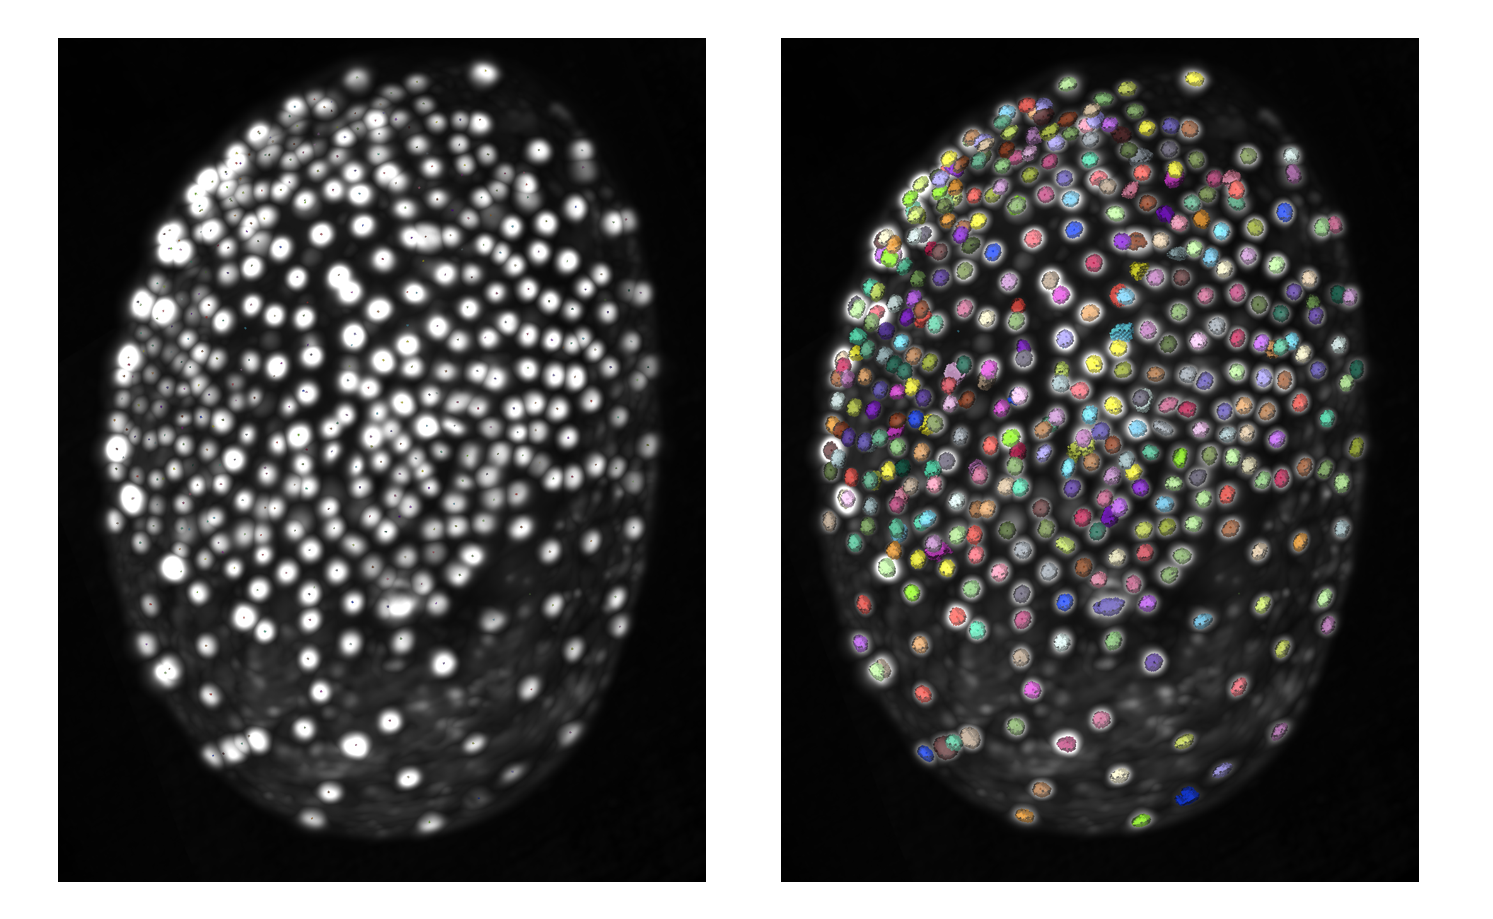

## Results for tmp = 500

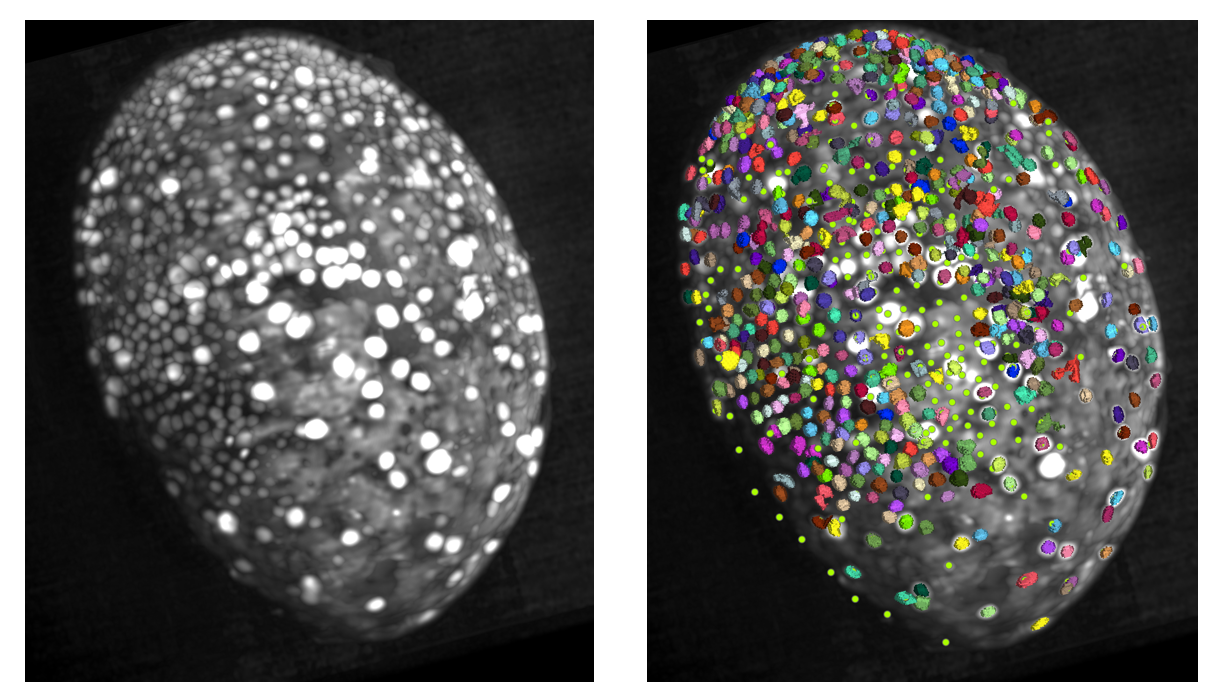